# Product Recommendation System

In [1]:
## Import Libraries
import warnings
warnings.filterwarnings('ignore')
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

## Data Collection
df = pd.read_csv("artifacts/data.csv", encoding='latin1')
display(df.head(5))
display(df.isnull().sum())

,Product,Quantity,Price,CustomerID
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850
1,WHITE METAL LANTERN,6,3.39,17850
2,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850
4,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850


Product       0
Quantity      0
Price         0
CustomerID    0
dtype: int64

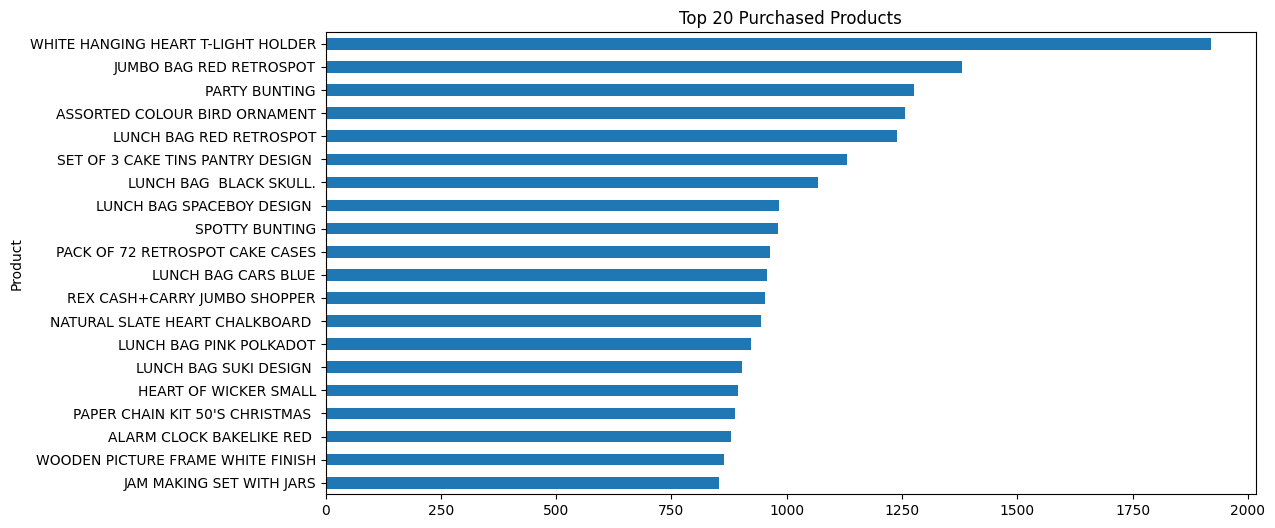

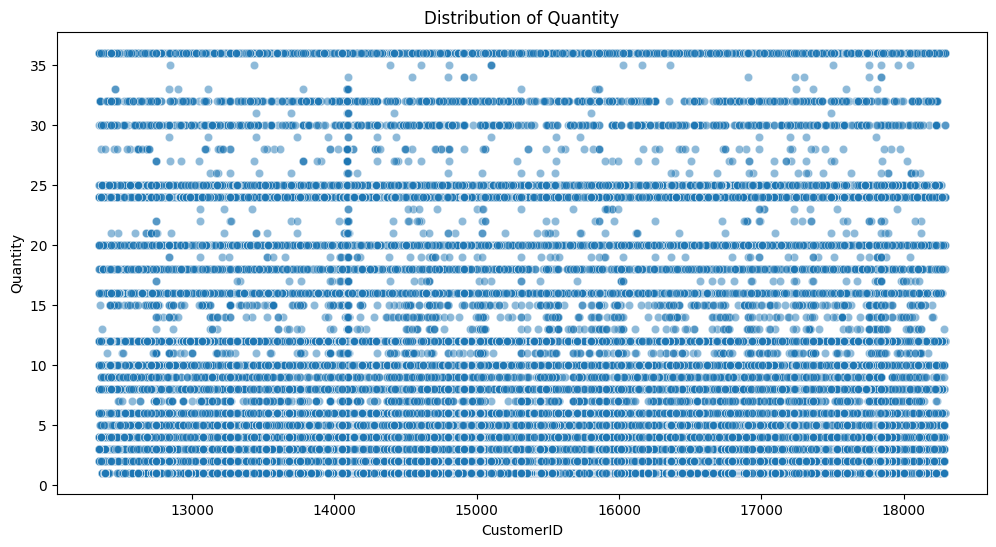

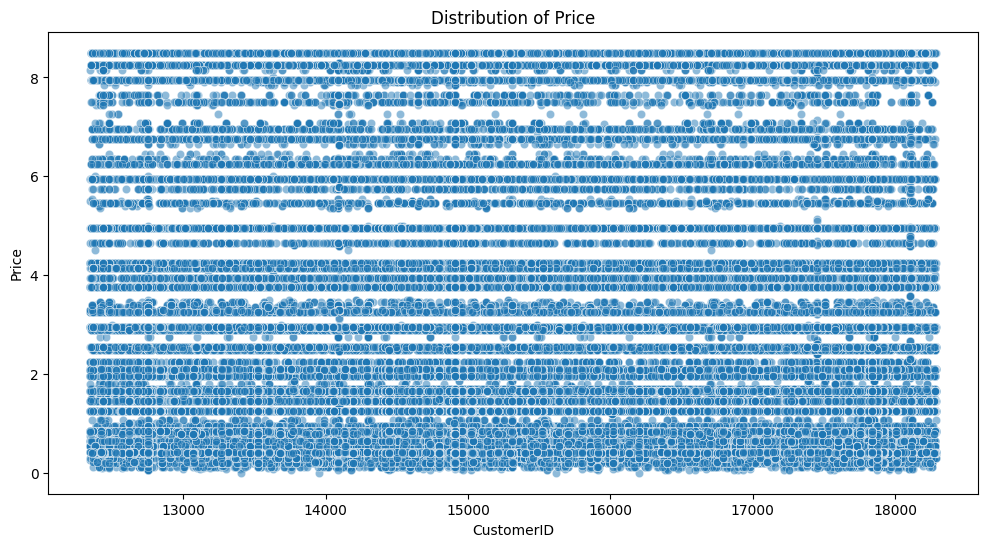

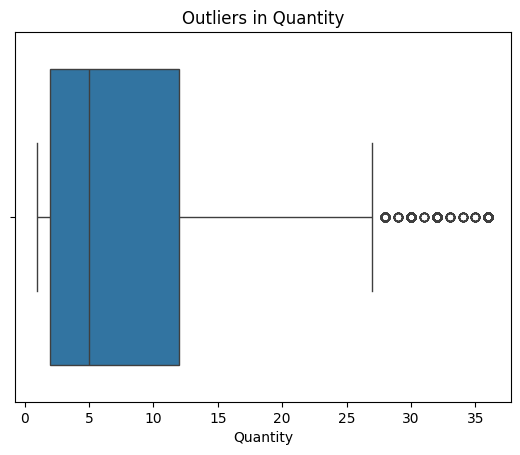

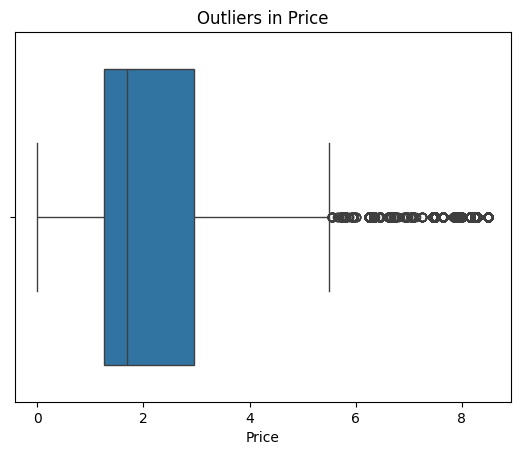

In [2]:
## Data Visualization 

num_cols = ['Quantity', 'Price']

### Top Products
plt.figure(figsize=(12,6))
df['Product'].value_counts().head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Purchased Products')
plt.savefig(f'static/Top Products')
plt.show()

### Univariate Analysis 
for col in num_cols:
    plt.figure(figsize=(12,6))
    sns.scatterplot(data=df, x="CustomerID", y=col, alpha=0.5)
    plt.title(f'Distribution of {col}')
    plt.savefig(f'static/Distribution_{col}')
    plt.show()

### Outlier Detection
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
    plt.savefig(f'static/Outliers_{col}')
    plt.show()

In [3]:
## Sparsity of Dataset
n_customers = df.CustomerID.nunique()
n_products = df.Product.nunique()
sparsity = (1 - len(df) / (n_customers * n_products))

print("Unique Users :", n_customers)
print("Unique Products :", n_products)
print(f"{sparsity * 100:.2f}% of user-item matrix is empty and only about {100 - (sparsity * 100):.2f}% of all possible user-item interactions are present.")

## Train Test Split
train_size = int(len(df) * 0.80)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

Unique Users : 4214
Unique Products : 3695
97.68% of user-item matrix is empty and only about 2.32% of all possible user-item interactions are present.


In [4]:
## Model Training

### Popularity Recommendation
popular_products = (train_df.groupby("Product")["Quantity"].sum()
    .sort_values(ascending=False).index.tolist())

def popularity_recommend(n = 5):
    return popular_products[:n]

    
### User Item Matrix 
user_item = train_df.pivot_table(index="CustomerID", columns="Product", values="Quantity",
                                aggfunc="sum", fill_value=0)

user_similarity = cosine_similarity(user_item)
item_similarity = cosine_similarity(user_item.T)
user_similarity_df = pd.DataFrame(user_similarity, index = user_item.index, columns = user_item.index)
item_similarity_df = pd.DataFrame(item_similarity, index = user_item.columns, columns = user_item.columns)


### User Based Collaborative Recommendation
def user_based_recommend(customer_id, top_n = 5):
    if customer_id not in user_item.index:
        return []

    similar_users = (user_similarity_df[customer_id].sort_values(ascending=False).iloc[1:6].index)
    purchased = (user_item.loc[customer_id])
    purchased = (purchased[purchased > 0].index)

    scores = {}
    for user in similar_users:
        items = user_item.loc[user]
        for product in items[items > 0].index:
            if product not in purchased:
                scores[product] = (scores.get(product, 0) + items[product])

    scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [x[0] for x in scores[:top_n]]


### Item Based Collaborative Recommendation
def item_based_recommend(product, top_n = 5):
    if product not in item_similarity_df.index:
        return []

    return (item_similarity_df[product].sort_values(ascending=False).iloc[1:top_n+1].index.tolist())


### Content Based Recommendation
product_data = (train_df[['Product']].drop_duplicates().reset_index(drop=True))
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(product_data['Product'])
content_similarity = cosine_similarity(tfidf_matrix)

content_similarity_df = pd.DataFrame(
    content_similarity,
    index=product_data['Product'],
    columns=product_data['Product']
)

def content_recommend(product, top_n = 5):
    if product not in content_similarity_df.index:
        return []

    return (
        content_similarity_df[product]
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
        .index
        .tolist()
    )


### Hybrid Recommendation
def hybrid_recommend(product, top_n = 5):
    
    if (product not in item_similarity_df.index or product not in content_similarity_df.index):
        return []

    hybrid_score = (item_similarity_df[product] * 0.6 + content_similarity_df[product] * 0.4)
    return (hybrid_score.sort_values(ascending=False).iloc[1:top_n+1].index.tolist())

In [5]:
## Model Evaluation

ground_truth = (test_df.groupby("CustomerID")["Product"].apply(set).to_dict())

K = 5
popularity_dict = {}
user_cf_dict = {}
item_cf_dict = {}
content_dict = {}
hybrid_dict = {}

for user in ground_truth.keys():
    popularity_dict[user] = (popularity_recommend(K))

    if user not in user_item.index:
        continue

    user_cf_dict[user] = (user_based_recommend(user, K))
    purchased = (user_item.loc[user])

    purchased = (
        purchased[purchased > 0]
        .index
        .tolist()
    )

    item_recs = []
    content_recs = []
    hybrid_recs = []

    for product in purchased[:3]:

        item_recs.extend(item_based_recommend(product, K))
        content_recs.extend(content_recommend(product, K))
        hybrid_recs.extend(hybrid_recommend(product, K))

    item_cf_dict[user] = (list(dict.fromkeys(item_recs))[:K])
    content_dict[user] = (list(dict.fromkeys(content_recs))[:K])
    hybrid_dict[user] = (list(dict.fromkeys(hybrid_recs))[:K])


# Performance Metrics 

test_user_items = (
    test_df.groupby("CustomerID")["Product"]
    .apply(set)
    .to_dict()
)
all_products = set(df["Product"].unique())

def precision_at_k(recommended, relevant, k = 5):
    recommended = recommended[:k]
    if len(recommended) == 0:
        return 0

    hits = len(set(recommended) & set(relevant))
    return hits / len(recommended)


def recall_at_k(recommended, relevant, k = 5):
    recommended = recommended[:k]
    if len(relevant) == 0:
        return 0

    hits = len(set(recommended) & set(relevant))
    return hits / len(relevant)


def f1_at_k(recommended, relevant, k = 5):
    p = precision_at_k(recommended, relevant, k)
    r = recall_at_k(recommended, relevant, k)

    if p + r == 0:
        return 0

    return 2 * p * r / (p + r)


def hit_rate_at_k(recommended, relevant, k = 5):
    recommended = recommended[:k]
    return int(len(set(recommended) & set(relevant)) > 0)


def average_precision(recommended, relevant, k = 5):
    score = 0
    hits = 0

    for i,item in enumerate(recommended[:k], start=1):
        if item in relevant:
            hits += 1
            score += hits / i

    if hits == 0:
        return 0

    return score / min(len(relevant), k)


def map_at_k(all_recommendations, ground_truth, k = 5):
    scores = []
    for user, recs in all_recommendations.items():
        if user in ground_truth:
            ap = average_precision(recs, ground_truth[user], k)
            scores.append(ap)

    return np.mean(scores)


def ndcg_at_k(recommended, relevant, k = 5):
    dcg = 0
    for i,item in enumerate(recommended[:k], start=1):
        if item in relevant:
            dcg += 1 / np.log2(i + 1)

    ideal_hits = min(len(relevant), k)
    idcg = sum(1 / np.log2(i + 1) for i in range(1, ideal_hits + 1))

    if idcg == 0:
        return 0

    return dcg / idcg


def coverage(all_recommendations):
    recommended_items = set()
    for recs in all_recommendations.values():
        recommended_items.update(recs)

    return (len(recommended_items) / len(all_products))


def diversity(recommended_items, similarity_matrix):
    if len(recommended_items) < 2:
        return 0

    distances = []
    for i in range(len(recommended_items)):
        for j in range(i+1, len(recommended_items)):

            item1 = recommended_items[i]
            item2 = recommended_items[j]
            sim = similarity_matrix.loc[item1, item2]

            distances.append(1 - sim)

    return np.mean(distances)


def personalization(all_recommendations):
    users = list(all_recommendations.keys())
    similarities = []

    for i in range(len(users)):
        for j in range(i+1, len(users)):

            rec1 = set(all_recommendations[users[i]])
            rec2 = set(all_recommendations[users[j]])
            union = len(rec1 | rec2)

            if union == 0:
                continue

            sim = len(rec1 & rec2) / union
            similarities.append(sim)

    if len(similarities) == 0:
        return 0

    return 1 - np.mean(similarities)

def evaluate_model(name, recommendations):
    precisions = []
    recalls = []
    f1s = []
    hits = []
    ndcgs = []


    for user,recs in recommendations.items():

        if user not in ground_truth:
            continue

        relevant = ground_truth[user]

        precisions.append(precision_at_k(recs, relevant, K))
        recalls.append(recall_at_k(recs, relevant, K))
        f1s.append(f1_at_k(recs, relevant, K))
        hits.append(hit_rate_at_k(recs, relevant, K))
        ndcgs.append(ndcg_at_k(recs, relevant, K))

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print(f"Precision@5     : {np.mean(precisions) * 100:.2f}%")
    print(f"Recall@5        : {np.mean(recalls) * 100:.2f}%")
    print(f"F1@5            : {np.mean(f1s) * 100:.2f}%")
    print(f"HitRate@5       : {np.mean(hits) * 100:.2f}%")
    print(f"MAP@5           : {map_at_k(recommendations, ground_truth, K) * 100:.2f}")
    print(f"NDCG@5          : {np.mean(ndcgs) * 100:.2f}%")
    print(f"Coverage        : {coverage(recommendations) * 100:.2f}")
    print(f"Personalization : {personalization(recommendations) * 100:.2f}%")



evaluate_model("Popularity", popularity_dict)
evaluate_model("User CF", user_cf_dict)
evaluate_model("Item CF", item_cf_dict)
evaluate_model("Content Based", content_dict)
evaluate_model("Hybrid", hybrid_dict)


Popularity
Precision@5     : 8.50%
Recall@5        : 1.91%
F1@5            : 2.49%
HitRate@5       : 31.74%
MAP@5           : 5.22
NDCG@5          : 9.20%
Coverage        : 0.14
Personalization : 0.00%

User CF
Precision@5     : 3.41%
Recall@5        : 0.77%
F1@5            : 1.09%
HitRate@5       : 13.81%
MAP@5           : 1.90
NDCG@5          : 3.56%
Coverage        : 32.10
Personalization : 99.23%

Item CF
Precision@5     : 4.78%
Recall@5        : 1.05%
F1@5            : 1.48%
HitRate@5       : 16.05%
MAP@5           : 3.13
NDCG@5          : 5.17%
Coverage        : 24.90
Personalization : 98.26%

Content Based
Precision@5     : 4.52%
Recall@5        : 1.05%
F1@5            : 1.45%
HitRate@5       : 16.60%
MAP@5           : 2.63
NDCG@5          : 4.62%
Coverage        : 25.60
Personalization : 97.89%

Hybrid
Precision@5     : 5.97%
Recall@5        : 1.40%
F1@5            : 1.93%
HitRate@5       : 19.93%
MAP@5           : 3.87
NDCG@5          : 6.45%
Coverage        : 26.41
Personali

In [6]:
## Model Serialization

### Downcast matrix values to float32 to reduce memory footprint by 50%
item_similarity_df = item_similarity_df.astype('float32')
content_similarity_df = content_similarity_df.astype('float32')
user_similarity_df = user_similarity_df.astype('float32')

### Ensure index & columns are generic objects for fast key matching
user_similarity_df.index = user_similarity_df.index.astype(object)
item_similarity_df.index = item_similarity_df.index.astype(object)
content_similarity_df.index = content_similarity_df.index.astype(object)

user_similarity_df.columns = user_similarity_df.columns.astype(object)
item_similarity_df.columns = item_similarity_df.columns.astype(object)
content_similarity_df.columns = content_similarity_df.columns.astype(object)


hybrid_model = {
    "item_similarity": item_similarity_df,
    "content_similarity": content_similarity_df,
    "item_weight": 0.6,
    "content_weight": 0.4
}

joblib.dump(popular_products, "artifacts/model_popular.pkl")
joblib.dump(user_item, "artifacts/model_user_item.pkl")
joblib.dump(user_similarity_df, "artifacts/model_cf_user.pkl")
joblib.dump(item_similarity_df, "artifacts/model_cf_item.pkl")
joblib.dump(content_similarity_df, "artifacts/model_content.pkl")
joblib.dump(hybrid_model, "artifacts/model_hybrid.pkl")

print("\nAll Models Saved.")


All Models Saved.
